In [2]:
Data.head(5)

,Power (W),Speed (cm/s),DPI,Defocus (inch),Sheet Resistance (ohm)
0,58,19,400,-0.1,7.1757
1,60,18,200,0.2,7.1757
2,50,17,600,-0.1,8.8641
3,56,18,300,-0.1,10.9746
4,55,16,400,-0.2,11.3967


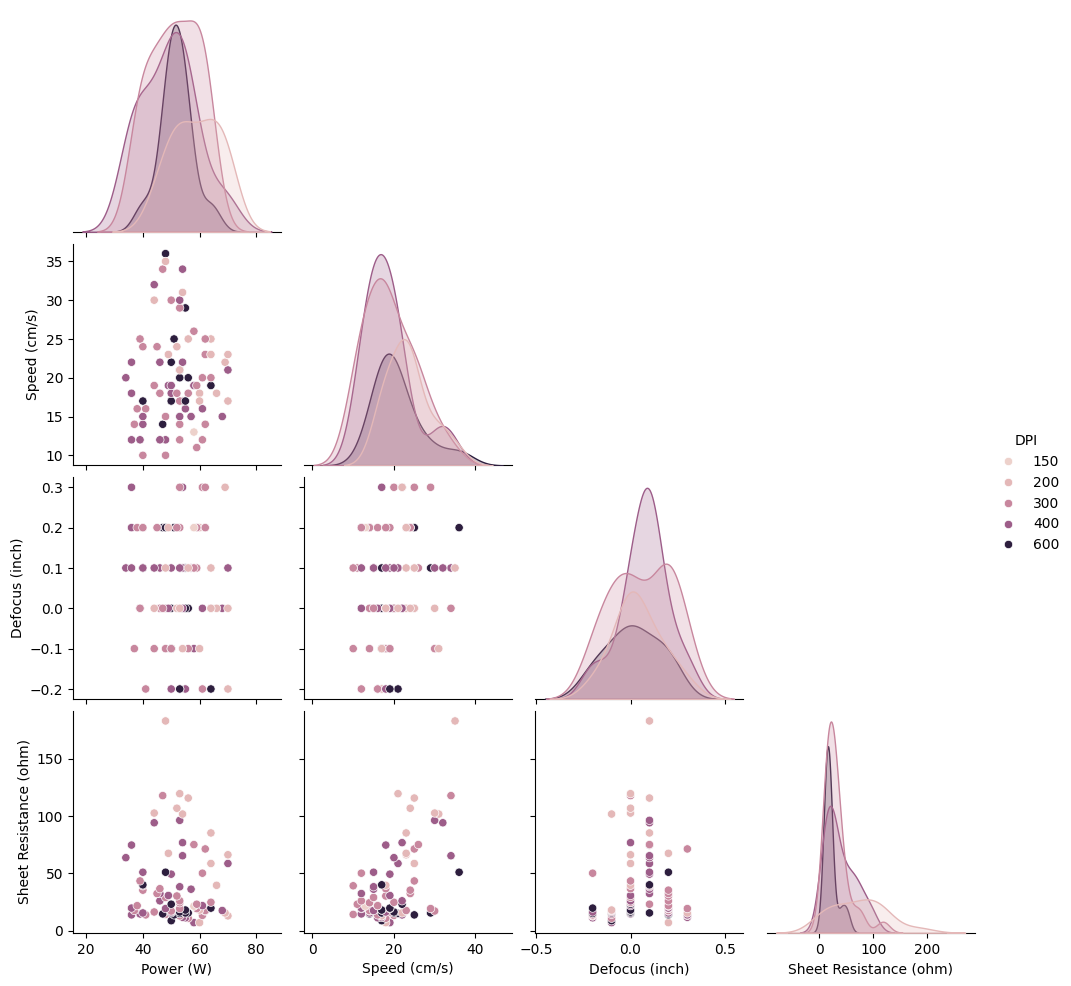

In [3]:
import pandas as pd
import numpy as np
url = 'https://github.com/mta-phy/5820x/raw/main/HWs/LIG.xlsx'
Data = pd.read_excel(url)
Power = Data.iloc[:, 0].to_numpy();
Speed = Data.iloc[:, 1].to_numpy();
DPI = Data.iloc[:, 2].to_numpy();
Defocus = Data.iloc[:, 3].to_numpy();
Sheet_resistance= Data.iloc[:, 4].to_numpy();


import seaborn as sns
import matplotlib.pyplot as plt

# Columns to visualize
cols = ["Power (W)", "Speed (cm/s)", "DPI", "Defocus (inch)",
        "Sheet Resistance (ohm)"]

sns.pairplot(Data[cols], diag_kind="kde", corner=True, hue="DPI")
plt.show()

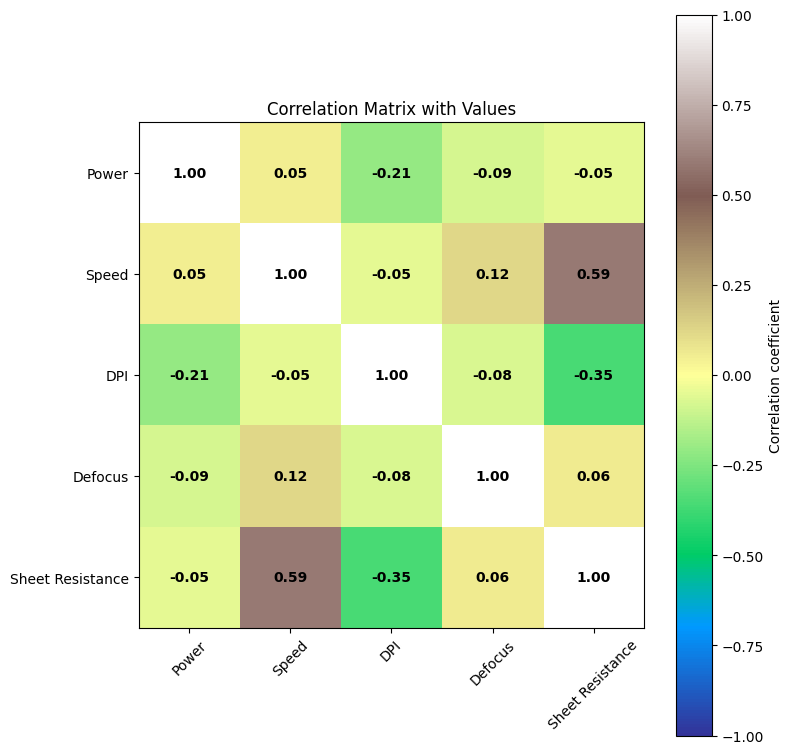

In [4]:
plt.figure(figsize=(8,8))
feature_names=['Power','Speed','DPI','Defocus','Sheet Resistance']

# Create the heatmap
cor = np.corrcoef(Data.iloc[:, 0:5], rowvar=False)
im = plt.imshow(cor, vmin=-1, vmax=1, cmap='terrain')
plt.colorbar(im, label="Correlation coefficient")

for i in range(len(feature_names)):
    for j in range(len(feature_names)):
            text = plt.text(j, i, f"{cor[i, j]:.2f}",
                       ha="center", va="center", color="black",
                       fontweight='bold')


plt.xticks(range(len(feature_names)), feature_names, rotation=45)
plt.yticks(range(len(feature_names)), feature_names)
plt.title("Correlation Matrix with Values")
plt.tight_layout()
plt.show()

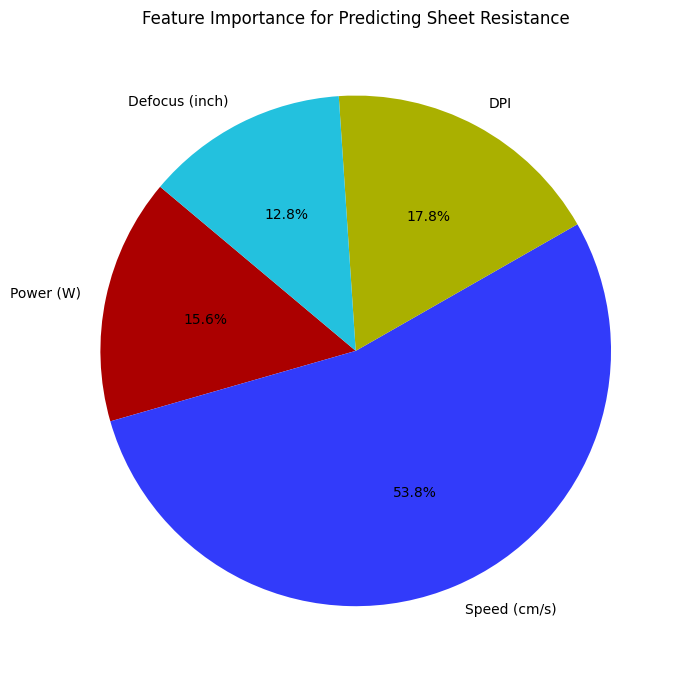

In [45]:
from sklearn.ensemble import RandomForestRegressor

X = Data[["Power (W)", "Speed (cm/s)", "DPI", "Defocus (inch)"]]
y = Data["Sheet Resistance (ohm)"]

rf = RandomForestRegressor(n_estimators=500, random_state=0)
rf.fit(X, y)

labels = X.columns
sizes = rf.feature_importances_

plt.figure(figsize=(7,7))
plt.pie(    sizes,    labels=labels,    autopct="%1.1f%%",    startangle=140,    colors=["#AB0000", "#323BFA", "#AAB000", "#23C1DE"])
plt.title("Feature Importance for Predicting Sheet Resistance")
plt.tight_layout()
plt.show()


# Random Forest

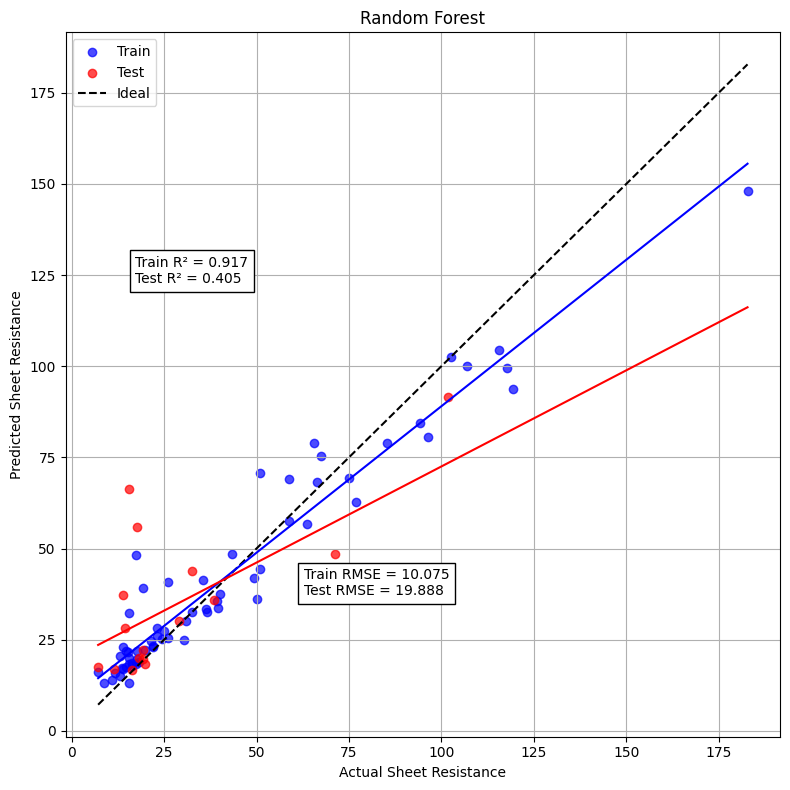

In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# Loading Excel
url = 'https://github.com/mta-phy/5820x/raw/main/HWs/LIG.xlsx'
df = pd.read_excel(url)

df.columns = df.columns.str.strip()

# Features (inputs) and target (output)
X = df[['Power (W)', 'Speed (cm/s)', 'DPI', 'Defocus (inch)']]
y = df['Sheet Resistance (ohm)']

# Data Splitting 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest model
model = RandomForestRegressor(
    n_estimators=400,
    random_state=42)


model.fit(X_train, y_train)


# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))


# Create plot
plt.figure(figsize=(8, 8))

# Scatter points
plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)
plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

# Ideal line (y = x)
min_val = min(y.min(), y_train_pred.min(), y_test_pred.min())
max_val = max(y.max(), y_train_pred.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')

# Fit regression lines
train_fit = np.polyfit(y_train, y_train_pred, 1)
test_fit = np.polyfit(y_test, y_test_pred, 1)

plt.plot([min_val, max_val],
         np.polyval(train_fit, [min_val, max_val]),
         color='blue', linestyle='-')

plt.plot([min_val, max_val],
         np.polyval(test_fit, [min_val, max_val]),
         color='red', linestyle='-')

# Labels
plt.xlabel("Actual Sheet Resistance")
plt.ylabel("Predicted Sheet Resistance")
plt.title("Random Forest")
# Text box for metrics
plt.text(min_val + 10, max_val - 60,
         f"Train R² = {train_r2:.3f}\nTest R² = {test_r2:.3f}",
         bbox=dict(facecolor='white'))

plt.text(max_val - 120, min_val + 30,
         f"Train RMSE = {train_rmse:.3f}\nTest RMSE = {test_rmse:.3f}",
         bbox=dict(facecolor='white'))

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Support Vector Regression (SVR)

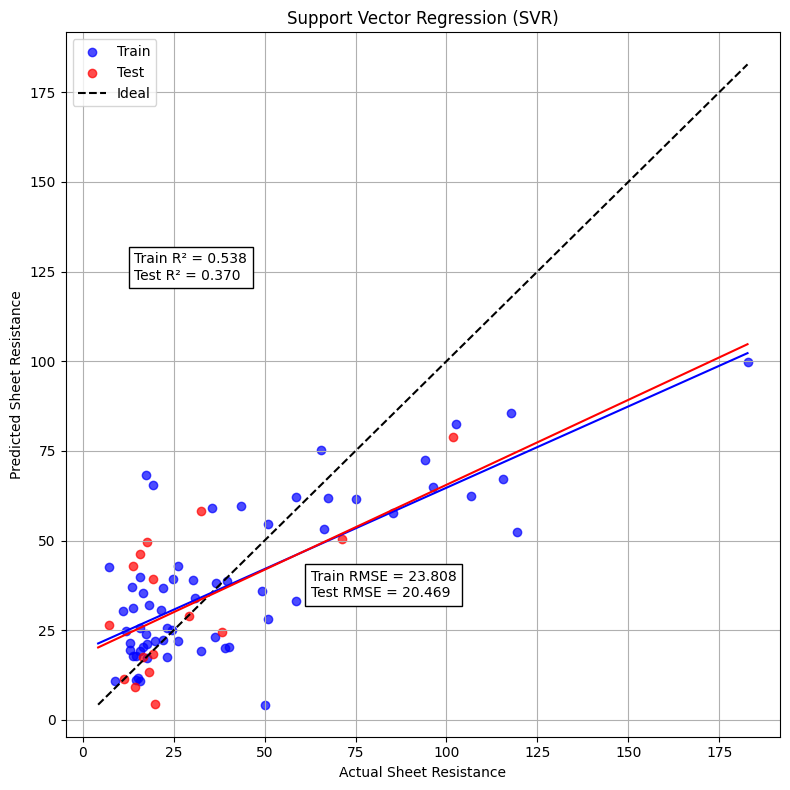

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load data
df = pd.read_excel("LIG.xlsx")
df.columns = df.columns.str.strip()

X = df[['Power (W)', 'Speed (cm/s)', 'DPI', 'Defocus (inch)']]
y = df['Sheet Resistance (ohm)']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------
# SCALE X and Y PROPERLY
# -------------------------
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_s = x_scaler.fit_transform(X_train)
X_test_s = x_scaler.transform(X_test)

y_train_s = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()

# -------------------------
# BETTER SVR SETTINGS
# -------------------------
model = SVR(
    kernel='rbf',
    C=10,          # MUCH smaller
    gamma=0.01,   # smoother function
    epsilon=0.1   # more tolerance (prevents overfitting)
)

model.fit(X_train_s, y_train_s)

# Predictions
y_train_pred_s = model.predict(X_train_s)
y_test_pred_s = model.predict(X_test_s)

# Inverse transform
y_train_pred = y_scaler.inverse_transform(y_train_pred_s.reshape(-1,1)).ravel()
y_test_pred = y_scaler.inverse_transform(y_test_pred_s.reshape(-1,1)).ravel()

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Create plot
plt.figure(figsize=(8, 8))

# Scatter points
plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)
plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

# Ideal line (y = x)
min_val = min(y.min(), y_train_pred.min(), y_test_pred.min())
max_val = max(y.max(), y_train_pred.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')

# Fit regression lines
train_fit = np.polyfit(y_train, y_train_pred, 1)
test_fit = np.polyfit(y_test, y_test_pred, 1)

plt.plot([min_val, max_val],
         np.polyval(train_fit, [min_val, max_val]),
         color='blue', linestyle='-')

plt.plot([min_val, max_val],
         np.polyval(test_fit, [min_val, max_val]),
         color='red', linestyle='-')

# Labels
plt.xlabel("Actual Sheet Resistance")
plt.ylabel("Predicted Sheet Resistance")
plt.title("Support Vector Regression (SVR)")
# Text box for metrics
plt.text(min_val + 10, max_val - 60,
         f"Train R² = {train_r2:.3f}\nTest R² = {test_r2:.3f}",
         bbox=dict(facecolor='white'))

plt.text(max_val - 120, min_val + 30,
         f"Train RMSE = {train_rmse:.3f}\nTest RMSE = {test_rmse:.3f}",
         bbox=dict(facecolor='white'))

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Decision Tree (DT)

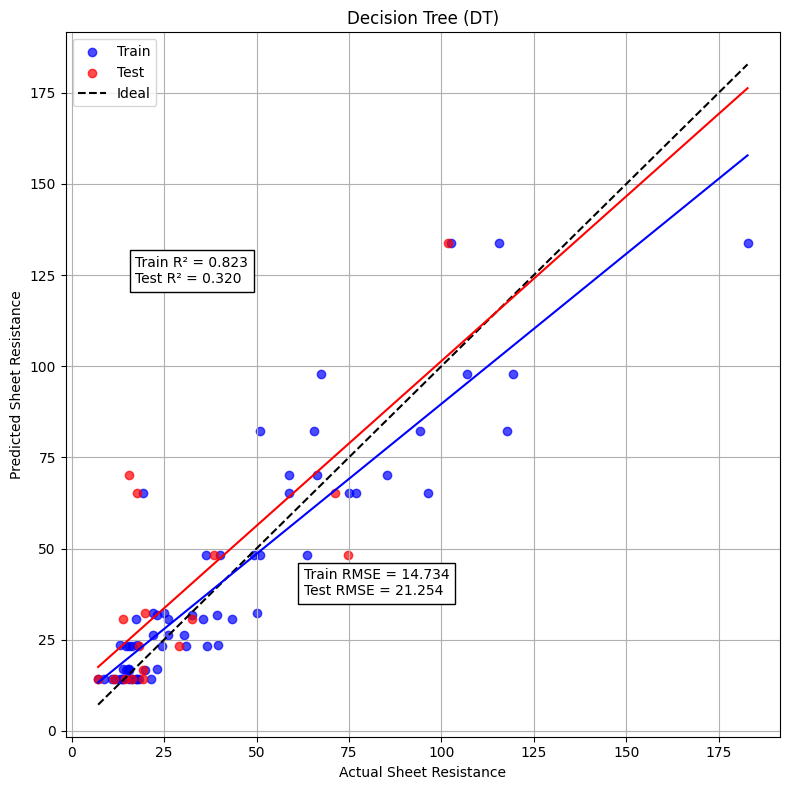

In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load data
df = pd.read_excel("LIG.xlsx")
df.columns = df.columns.str.strip()

X = df[['Power (W)', 'Speed (cm/s)', 'DPI', 'Defocus (inch)']]
y = df['Sheet Resistance (ohm)']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 
model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5,
    min_samples_leaf=3
)

model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# -----------------------
# METRICS

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Create plot
plt.figure(figsize=(8, 8))

# Scatter points
plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)
plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

# Ideal line (y = x)
min_val = min(y.min(), y_train_pred.min(), y_test_pred.min())
max_val = max(y.max(), y_train_pred.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')

# Fit regression lines
train_fit = np.polyfit(y_train, y_train_pred, 1)
test_fit = np.polyfit(y_test, y_test_pred, 1)

plt.plot([min_val, max_val],
         np.polyval(train_fit, [min_val, max_val]),
         color='blue', linestyle='-')

plt.plot([min_val, max_val],
         np.polyval(test_fit, [min_val, max_val]),
         color='red', linestyle='-')

# Labels
plt.xlabel("Actual Sheet Resistance")
plt.ylabel("Predicted Sheet Resistance")
plt.title("Decision Tree (DT)")
# Text box for metrics
plt.text(min_val + 10, max_val - 60,
         f"Train R² = {train_r2:.3f}\nTest R² = {test_r2:.3f}",
         bbox=dict(facecolor='white'))

plt.text(max_val - 120, min_val + 30,
         f"Train RMSE = {train_rmse:.3f}\nTest RMSE = {test_rmse:.3f}",
         bbox=dict(facecolor='white'))

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# K-Nearest Neighbors (KNN) 

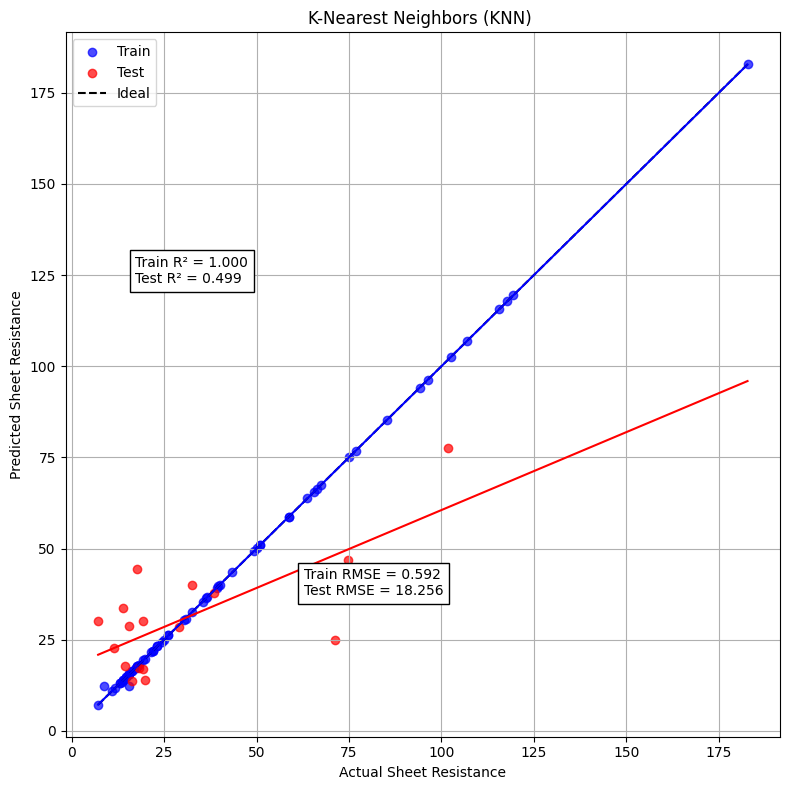

In [34]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load data
df = pd.read_excel("LIG.xlsx")
df.columns = df.columns.str.strip()

X = df[['Power (W)', 'Speed (cm/s)', 'DPI', 'Defocus (inch)']]
y = df['Sheet Resistance (ohm)']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------
# SCALING (VERY IMPORTANT)
# -----------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# -----------------------
# KNN MODEL
# -----------------------
model = KNeighborsRegressor(
    n_neighbors=4,   # you can tune this
    weights='distance'  # better than uniform for regression
)

model.fit(X_train_s, y_train)

# Predictions
y_train_pred = model.predict(X_train_s)
y_test_pred = model.predict(X_test_s)

# -----------------------
# METRICS

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Create plot
plt.figure(figsize=(8, 8))

# Scatter points
plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)
plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

# Ideal line (y = x)
min_val = min(y.min(), y_train_pred.min(), y_test_pred.min())
max_val = max(y.max(), y_train_pred.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')

# Fit regression lines
train_fit = np.polyfit(y_train, y_train_pred, 1)
test_fit = np.polyfit(y_test, y_test_pred, 1)

plt.plot([min_val, max_val],
         np.polyval(train_fit, [min_val, max_val]),
         color='blue', linestyle='-')

plt.plot([min_val, max_val],
         np.polyval(test_fit, [min_val, max_val]),
         color='red', linestyle='-')

# Labels
plt.xlabel("Actual Sheet Resistance")
plt.ylabel("Predicted Sheet Resistance")
plt.title("K-Nearest Neighbors (KNN) ")
# Text box for metrics
plt.text(min_val + 10, max_val - 60,
         f"Train R² = {train_r2:.3f}\nTest R² = {test_r2:.3f}",
         bbox=dict(facecolor='white'))

plt.text(max_val - 120, min_val + 30,
         f"Train RMSE = {train_rmse:.3f}\nTest RMSE = {test_rmse:.3f}",
         bbox=dict(facecolor='white'))

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Neural Network

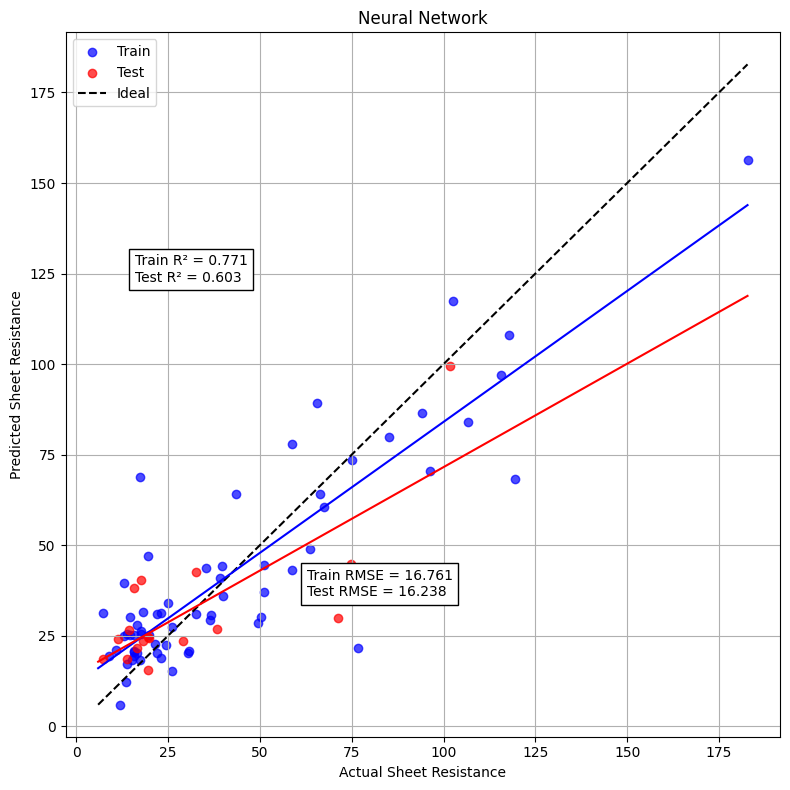

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline

# Load data
df = pd.read_excel("LIG.xlsx")
df.columns = df.columns.str.strip()

X = df[['Power (W)', 'Speed (cm/s)', 'DPI', 'Defocus (inch)']]
y = df['Sheet Resistance (ohm)']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline([
    ("scaler_X", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(16, 8),
        activation='relu',
        solver='adam',
        alpha=0.01,              # stronger regularization
        learning_rate_init=0.0005,
        max_iter=5000,
        early_stopping=True,     # prevents overfitting
        n_iter_no_change=50,
        random_state=42
    ))
])

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Create plot
plt.figure(figsize=(8, 8))

# Scatter points
plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)
plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

# Ideal line (y = x)
min_val = min(y.min(), y_train_pred.min(), y_test_pred.min())
max_val = max(y.max(), y_train_pred.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')

# Fit regression lines
train_fit = np.polyfit(y_train, y_train_pred, 1)
test_fit = np.polyfit(y_test, y_test_pred, 1)

plt.plot([min_val, max_val],
         np.polyval(train_fit, [min_val, max_val]),
         color='blue', linestyle='-')

plt.plot([min_val, max_val],
         np.polyval(test_fit, [min_val, max_val]),
         color='red', linestyle='-')

# Labels
plt.xlabel("Actual Sheet Resistance")
plt.ylabel("Predicted Sheet Resistance")
plt.title("Neural Network")
# Text box for metrics
plt.text(min_val + 10, max_val - 60,
         f"Train R² = {train_r2:.3f}\nTest R² = {test_r2:.3f}",
         bbox=dict(facecolor='white'))

plt.text(max_val - 120, min_val + 30,
         f"Train RMSE = {train_rmse:.3f}\nTest RMSE = {test_rmse:.3f}",
         bbox=dict(facecolor='white'))

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# XGBoost

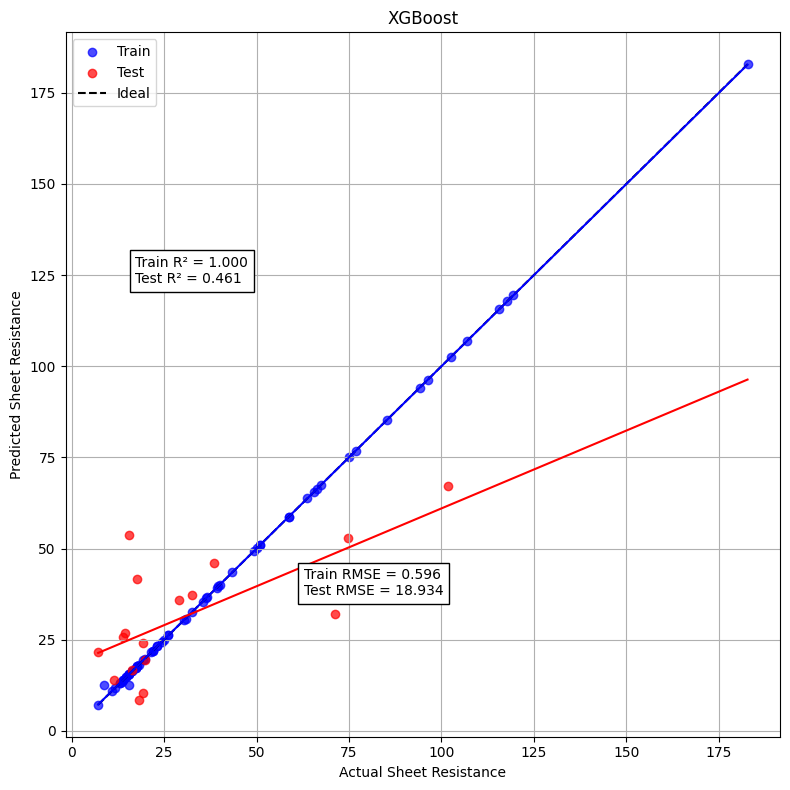

In [37]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Load data
df = pd.read_excel("LIG.xlsx")
df.columns = df.columns.str.strip()

X = df[['Power (W)', 'Speed (cm/s)', 'DPI', 'Defocus (inch)']]
y = df['Sheet Resistance (ohm)']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



# XGBoost model
model = xgb.XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Create plot
plt.figure(figsize=(8, 8))

# Scatter points
plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)
plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

# Ideal line (y = x)
min_val = min(y.min(), y_train_pred.min(), y_test_pred.min())
max_val = max(y.max(), y_train_pred.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')

# Fit regression lines
train_fit = np.polyfit(y_train, y_train_pred, 1)
test_fit = np.polyfit(y_test, y_test_pred, 1)

plt.plot([min_val, max_val],
         np.polyval(train_fit, [min_val, max_val]),
         color='blue', linestyle='-')

plt.plot([min_val, max_val],
         np.polyval(test_fit, [min_val, max_val]),
         color='red', linestyle='-')

# Labels
plt.xlabel("Actual Sheet Resistance")
plt.ylabel("Predicted Sheet Resistance")
plt.title("XGBoost")
# Text box for metrics
plt.text(min_val + 10, max_val - 60,
         f"Train R² = {train_r2:.3f}\nTest R² = {test_r2:.3f}",
         bbox=dict(facecolor='white'))

plt.text(max_val - 120, min_val + 30,
         f"Train RMSE = {train_rmse:.3f}\nTest RMSE = {test_rmse:.3f}",
         bbox=dict(facecolor='white'))

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

CATboost

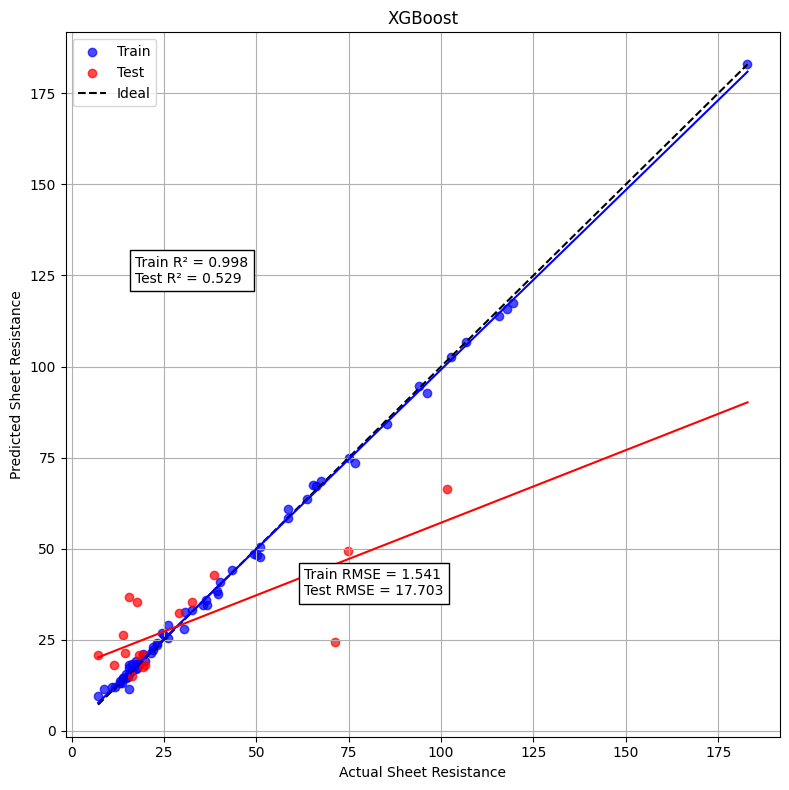

In [38]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from catboost import CatBoostRegressor



# Load data
df = pd.read_excel("LIG.xlsx")
df.columns = df.columns.str.strip()

X = df[['Power (W)', 'Speed (cm/s)', 'DPI', 'Defocus (inch)']]
y = df['Sheet Resistance (ohm)']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = CatBoostRegressor(
    iterations=1000,
    depth=5,
    learning_rate=0.03,
    loss_function='RMSE',
    random_seed=42,
    verbose=False
)
# Train
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Create plot
plt.figure(figsize=(8, 8))

# Scatter points
plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)
plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

# Ideal line (y = x)
min_val = min(y.min(), y_train_pred.min(), y_test_pred.min())
max_val = max(y.max(), y_train_pred.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')

# Fit regression lines
train_fit = np.polyfit(y_train, y_train_pred, 1)
test_fit = np.polyfit(y_test, y_test_pred, 1)

plt.plot([min_val, max_val],
         np.polyval(train_fit, [min_val, max_val]),
         color='blue', linestyle='-')

plt.plot([min_val, max_val],
         np.polyval(test_fit, [min_val, max_val]),
         color='red', linestyle='-')

# Labels
plt.xlabel("Actual Sheet Resistance")
plt.ylabel("Predicted Sheet Resistance")
plt.title("XGBoost")
# Text box for metrics
plt.text(min_val + 10, max_val - 60,
         f"Train R² = {train_r2:.3f}\nTest R² = {test_r2:.3f}",
         bbox=dict(facecolor='white'))

plt.text(max_val - 120, min_val + 30,
         f"Train RMSE = {train_rmse:.3f}\nTest RMSE = {test_rmse:.3f}",
         bbox=dict(facecolor='white'))

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()